## ADA final exam (Fall 2022)

This exam consists of 3 tasks. Tasks 2 and 3 are independent of each other (although conceptually related).


## Dataset

For a Wikipedia editor to become an administrator, a so-called “request for adminship” ([RfA](https://en.wikipedia.org/wiki/Wikipedia:Requests_for_adminship)) must be submitted by either the candidate or another community member. Subsequently, any Wikipedia member may cast a supporting or opposing vote. Here we provide a simplified version of the Wikipedia RfA dataset, containing all votes from 2003 through 2012.

###  Data format

|        |   SRC |   TGT |   VOT |   RES |   YEA | DAT                 | TXT                                                                                                                                                                                               |
|-------:|------:|------:|------:|------:|------:|:--------------------|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|  39054 |  3444 | 10170 |     1 |     1 |  2009 | 2009-07-01 17:50:00 | '''Support''' - Best of luck. &nbsp;                                                                                                                                                              |
| 159680 |   722 |  9634 |    -1 |    -1 |  2006 | 2006-12-15 07:28:00 | '''Oppose''' Not even 2000 edits.                                                                                                                                                                 |
| 173438 |  4194 |  5524 |     1 |     1 |  2005 | 2005-03-18 19:22:00 | Ohhh, you're Carrp!  In that case, '''Support'''.                                                                                                                                                 |
|  60627 |  4855 |  9436 |     1 |     1 |  2008 | 2008-12-18 23:26:00 | '''Support''' via thoughtful answer to my question that demonstrates this editor has clue.                                                 |
| 194809 |  7687 |   908 |     1 |     1 |  2004 | 2004-09-25 05:21:00 | Nicholas is very good in English. Also, he got '''exceptional''' patience to explain petty obvious facts in talk page to convince ignorants. Let the world be benefitted more out of his work. -- |


- SRC: the user name of the source of the vote, i.e., of the user who cast the vote.
- TGT: the user name of the target of the vote, i.e., of the user running for election.
- VOT: the source's vote on the target (-1 = oppose; 1 = support).
- RES: the outcome of the election (-1 = target was rejected as admin; 1 = target was accepted). **(We will not use this  column in this exam.)**
- YEA: the year of the RfA.
- DAT: the date and time of this vote. **(We will not use this column in this exam.)**
- TXT: the comment written by the source. **(We will not use this column in this exam.)**

---


## Structural balance theory

**Structural balance theory** affirms that social networks tend to be organized so as to avoid conflictual situations, e.g., if a great friend of yours hates someone, you will likely not befriend that person.

The theory can be operationalized by looking at _triangles_ in an undirected _signed graph_ capturing person-to-person relationships, where a _signed graph_ is a  graph in which each edge is associated with a positive or negative sign, and a _triangle_ is a set of three edges ($\langle u,v \rangle$, $\langle v,w\rangle$, $\langle u,w\rangle$) that fully connect three distinct nodes ($u, v, w$).



_Triangles_ in an undirected signed graph can be in 4 _configurations_:
all positive edges ($\{+,+,+\}$); 
all negative edges ($\{-,-,-\}$); 
two positive edges and one negative edge ($\{+,+,-\}$);
one positive edge and two negative edges ($\{+,-,-\}$).

Structural balance theory posits that social networks tend to favor triangle configurations with an even number of negative signs (i.e., $\{+,+,+\}$ and $\{+,-,-\}$), which can be understood as being “balanced” by avoiding conflictual situations. Intuitively, $\{+,+,+\}$ could be tagged as “The friend of my friend is my friend”, and $\{+,-,-\}$ as “The enemy of my enemy is my friend”, “The friend of my enemy is my enemy”, or “The enemy of my friend is my enemy”. On the contrary, triangle configurations with an odd number of negative signs (i.e., $\{+,+,-\}$ and $\{-,-,-\}$) are unstable (“unbalanced”) according to structural balance theory and will thus occur less frequently in social networks. For instance, me being friends with two mutual enemies ($\{+,+,-\}$) would lead to tension that could be resolved if the two enemies became friends or if I took sides and ended my friendship with one of the two. Similarly, two among three mutual enemies ($\{-,-,-\}$) would have the incentive to form an alliance to “gang up” against the third.

Some social scientists have argued that three mutual enemies ($\{-,-,-\}$) is not necessarily a triangle configuration that social networks tend to avoid. This gives rise to **weak structural balance theory**, which only posits that social networks tend to avoid the “unbalanced” triangle configuration $\{+,+,-\}$.

In a nutshell,
- structural balance theory
  - considers $\{+,+,+\}$, $\{+,-,-\}$ as balanced,
  - and $\{+,+,-\}$, $\{-,-,-\}$ as unbalanced;
- weak structural balance theory
  - considers $\{+,+,+\}$, $\{+,-,-\}$, $\{-,-,-\}$ as balanced,
  - and $\{+,+,-\}$ as unbalanced.



### Task 1: Preliminaries

As a good data scientist, you first load the data and explore it.

**1.1**
Load the csv file `wiki-RfA.csv.gz` in a pandas dataframe. Calculate the number of distinct RfAs and the average number of votes per RfA.
- **Hint:** Throughout this question, assume that each RfA is uniquely determined by the column `TGT` and each vote is uniquely determined by the combination of `SRC` and `TGT`.

In [223]:
# 1.1
import pandas as pd

df = pd.read_csv("wiki-RfA.csv.gz")

In [21]:
rfa_count = df["TGT"].nunique()
votes_count = df.shape[0]

In [25]:
print(f"Number of distinct RfAs: {rfa_count}")
print(f"Number of votes: {votes_count}")
print(f"Average number of votes per RfA: {votes_count / rfa_count:.3f}")

Number of distinct RfAs: 3439
Number of votes: 167003
Average number of votes per RfA: 48.562


**1.2** 
In a single figure with three subfigures (one per item), show the following time series:
- the number of RfAs per year;
- the overall fraction of positive votes per year; and 
- the average number of votes per RfA per year.

For each of the above three quantities, print the value for the year 2008.

In [52]:
rfa_per_year = df.groupby(["YEA"])["TGT"].agg(lambda group: group.nunique())
positive_votes_per_year = df.groupby(["YEA"])["VOT"].agg(lambda group: group[group == 1].count() / group.count())
avg_votes_per_rfa_per_year = df.groupby(["YEA"])["VOT"].agg(lambda group: group.count()) / rfa_per_year

In [65]:
print(f"Number of RfAs in 2008: {rfa_per_year.loc[2008]}")
print(f"Fraction of positive votes in 2008: {positive_votes_per_year.loc[2008]}")
print(f"Average number of votes per RfA in 2008: {avg_votes_per_rfa_per_year.loc[2008]}")

Number of RfAs in 2008: 520
Fraction of positive votes in 2008: 0.7612268475384787
Average number of votes per RfA in 2008: 51.60192307692308


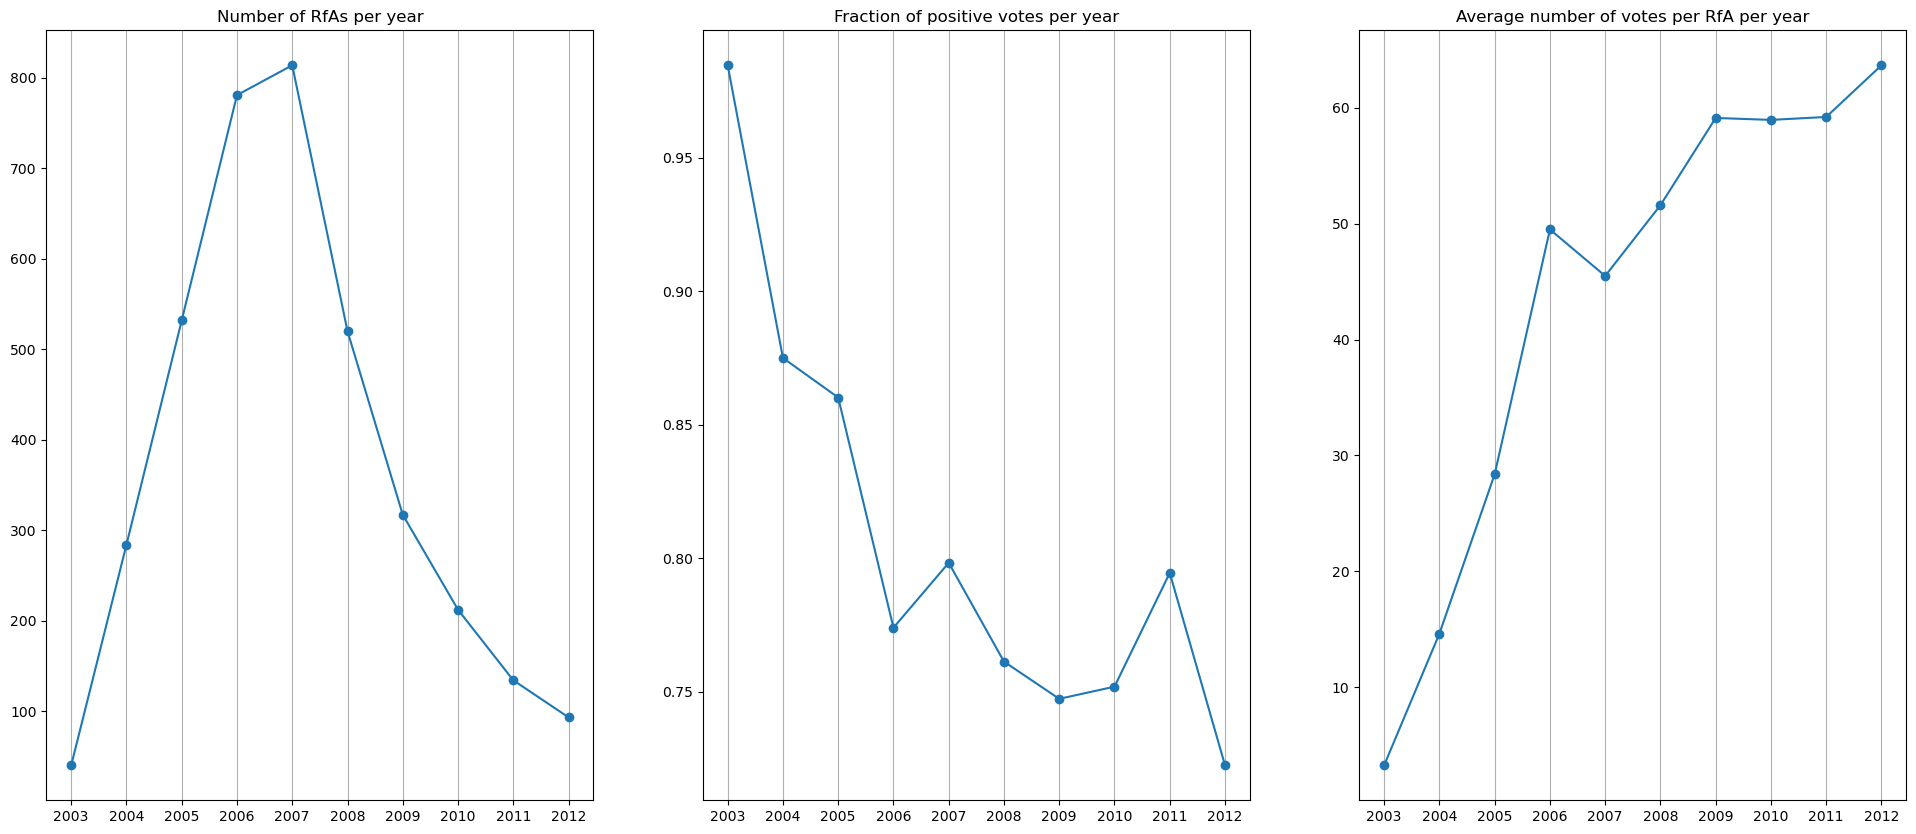

In [107]:
# 1.2
import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=3, figsize=(24, 10))

ax[0].plot(rfa_per_year, marker="o")
ax[0].set_title("Number of RfAs per year")
ax[0].set_xticks(rfa_per_year.index)
ax[0].xaxis.grid(True)

ax[1].plot(positive_votes_per_year, marker="o")
ax[1].set_title("Fraction of positive votes per year")
ax[1].set_xticks(positive_votes_per_year.index)
ax[1].xaxis.grid(True)

ax[2].plot(avg_votes_per_rfa_per_year, marker="o")
ax[2].set_title("Average number of votes per RfA per year")
ax[2].set_xticks(avg_votes_per_rfa_per_year.index)
ax[2].xaxis.grid(True)

plt.show()

**1.3** 
**/Discuss:/** Describe the temporal patterns observed in the plots you did in **T1.2**.

**A1.3** 

From the plots we can observe various temporal patterns:
- The number of RfAs per year rapidly grows from 2003 to 2007 where it reaches a peak. Growth was already beginning to slow down between 2006 and 2007, but it's after 2007 that it completely stops as the number of RfAs per year starts going down. The most intense drop of RfA is between 2007 and 2009, after that, while the number of RfAs keeps on decreasing, it seems to be starting to bottoming out at around $100$ RfAs per year.
- The fraction of positive votes per year starts very high in 2003 ($\approx 0.98$), but it starts dropping intensively after that, stopping briefly in 2007 and 2011 with small rises in positivity. 
- The average number of votes per RfA interestingly enough keeps on increasing, meaningfully stopping only in 2007.

The main interesting insight we can draw other than that the general trends is that 2007 was a very peculiar year as it's the year where the most RfAs were submitted, but also the only year where the average number of votes per RfA decreased significantly (which makes sense as a lot more RfAs were submitted). The peculiar part is that the fraction of positive votes went up in that year, meaning that the Wikipedia community generally embraced this surge of requests instead of trying to limit the number of new administrators, they preferred honest and supportive reviews (the opposite of the gatekeeping common in online communities).

**1.4** 
Create an undirected graph ([`nx.Graph`](https://networkx.org/documentation/stable/reference/classes/graph.html)) where every node corresponds to a Wikipedia user (source or target of an RfA) and where there exists an edge between two users if at least one of them has voted on the other. Each edge should have attributes corresponding to columns of the dataframe, namely:
- `VOT`, which equals `1` if the vote was positive, and `-1` otherwise.
- `YEA`, an integer that represents the year of the RfA.

**The code to load the graph has been provided to you!** After running it, print the number of nodes and edges in your graph.

---

**Observation:** Note that we have at most one edge per pair of nodes in the graph, even though two votes may be associated with the pair  — e.g., if A voted in B's RfA in time $t_1$ and B voted in A's RfA in time $t_2$ ($t_1 < t_2$). In these cases, the code provided associates the metadata of the oldest vote ($t_1$ in the example) to the edge between A and B.

In [3]:
# Provided code! Do not change!
import networkx as nx
import pandas as pd
G = nx.from_pandas_edgelist(pd.read_csv("./wiki-RfA.csv.gz"),
                            'SRC', 'TGT', ['VOT', 'RES', 'YEA', 'DAT'], create_using=nx.Graph)

In [84]:
# 1.4
print(f"Number of nodes in the graph: {len(G.nodes)}")
print(f"Number of edges in the graph: {len(G.edges)}")

Number of nodes in the graph: 10831
Number of edges in the graph: 161147


**1.5** 
Plot the **complementary** cumulative distribution of the degree centrality of the undirected graph. Use a logarithmic (base 10) x-axis and a linear y-axis.

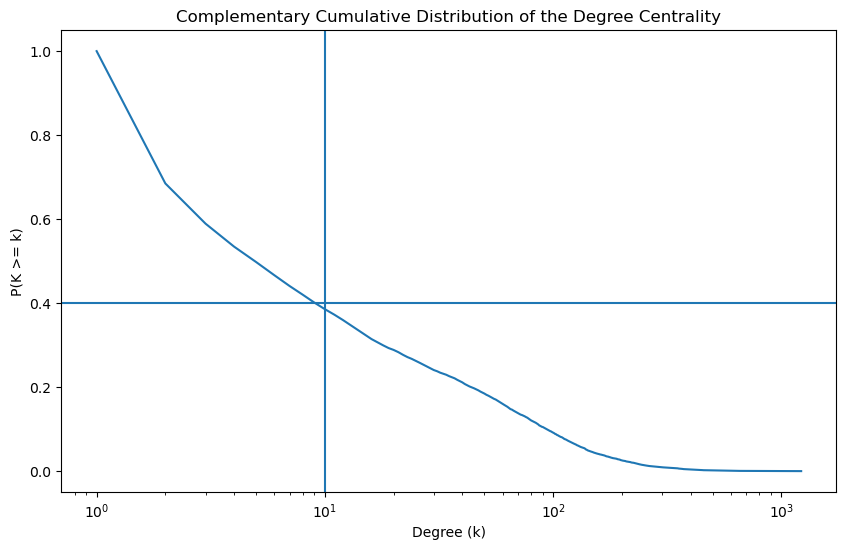

In [110]:
# 1.5
from typing import Counter

import numpy as np


degrees = [d for n, d in G.degree()]

degree_counts = Counter(degrees)
sorted_degrees = sorted(degree_counts.keys())
counts = [degree_counts[d] for d in sorted_degrees]

total_nodes = len(G.nodes)
ccdf_values = np.cumsum(counts[::-1])[::-1] / total_nodes # Probability P(K >= k)

plt.figure(figsize=(10, 6))
plt.plot(sorted_degrees, ccdf_values)
plt.xscale("log")
plt.axvline(10)
plt.axhline(0.4)
plt.title('Complementary Cumulative Distribution of the Degree Centrality')
plt.xlabel('Degree (k)')
plt.ylabel('P(K >= k)')
plt.show()


**1.6**
**/Discuss:/** Why is the following statement false? Justify your answer. **"From the graph obtained in task 1.5, one can conclude that around 40% of the users voted at least 11 times."**


**A1.6**

In this graph nodes represent Wikipedia users that either received a vote or voted, from the CCDF we can tell that about 40% of users voted or received a vote 11 times, so we can only say that an upper bound for the percentage of people that voted at least 11 times is 40%. 

**1.7**
What fraction of users voted at least 11 times? Use the data to measure the fraction.

In [131]:
# 1.7

vote_counts_per_voter = df.groupby("SRC")["TGT"].count()
n_voters = pd.concat([df["SRC"], df["TGT"]]).unique()

print(f"Percentage of voters that voted at least 11 times: {vote_counts_per_voter[vote_counts_per_voter >= 11].count() / len(n_voters)}")

Percentage of voters that voted at least 11 times: 0.24863816822084756


### Task 2: Triangles

Next, you set out to investigate the social balance theory by looking at the RfA graph.

**2.1**
Considering _only_ the RfAs of 2004 (i.e., where `YEA == 2004`), generate all triangles in the undirected graph.
Print the number of triangles found.
- **Hint:** Note that you can generate a graph with only a subset of nodes and edges via ` G.edge_subgraph`.
-  **Hint:** The function `nx.enumerate_all_cliques` generates all cliques in an undirected graph. First, all cliques of size 1 are generated, then all cliques of size 2, etc. Triangles are cliques of size 3.


In [ ]:
# 2.1

edges_2004 = [(u, v) for u, v, e in G.edges(data=True) if e["YEA"] == 2004]
G_2004 = G.edge_subgraph(edges_2004)

triangles = []
for clique in nx.enumerate_all_cliques(G_2004):
    if len(clique) > 3:
        break
    elif len(clique) == 3:
        triangles.append(clique)

print(f"The number of triangles considering only the RfAs of 2004 is {len(triangles)}")

The number of triangles considering only the RfAs of 2004 is 8448


**2.2 ** **/True or false:/** Is the following statement true or false? Justify your answer. **"The node with the highest clustering coefficient in an undirected graph is the node that belongs to the largest number of triangles."**

**A2.2**

False, the clustering coefficient does consider the number of triangles that the node belongs to but in a relative way to the number of neighbors the node has. Therefore, we cannot use the clustering coefficient to know the node that belongs in the most absolute number of triangles. For example the clustering coefficient of a node with two neighbors that have an edge between them is 1 and the node belongs to only one triangle, while a node with 4 neighbors with two edges between them has a clustering coefficient less that 1 with 2 even if it belongs to two different triangles. 

**2.3** Considering the set of triangles previously calculated, estimate the fraction of triangles of configurations
 $\{+,+,+\}$,  $\{-,-,-\}$,  $\{+,+,-\}$, and $\{+,-,-\}$. What fraction of triangles are "balanced" according to structural balance theory?

In [192]:
# 2.3

balanced_triangles = 0
for triangle in triangles:
    x = nx.get_edge_attributes(G.subgraph(triangle), "VOT")
    triangle_sum = sum([sign for (u, v), sign in x.items()])
    if triangle_sum == 3 or triangle_sum == -1:
        balanced_triangles += 1

print(f"Percentage of triangles that are balanced: {balanced_triangles / len(triangles)}")

Percentage of triangles that are balanced: 0.8553503787878788


**2.4** To observe how triangle configurations would be distributed under a random null model, do the following:
- Create a new column `VOT_RND` in the dataframe, where RfA votes (i.e., edge signs in the graph) are shuffled, i.e., permuted randomly.  For shuffling, use `numpy.random`, without replacement and with the seed 32 (see code provided below).
- Create a new edge attribute with the values of `VOT_RND` in the graph you created in task **1.4**. You can do this easily using the  [`set_edge_attributes`](https://networkx.org/documentation/stable/reference/generated/networkx.classes.function.set_edge_attributes.html) function.
- Considering the shuffled edge signs,  compute the fraction of triangles in each configuration ($\{+,+,+\}$,  $\{-,-,-\}$,  $\{+,+,-\}$, $\{+,-,-\}$). Moreover, compute the fraction of triangles that are "balanced" according to structural balance theory. (Reminder: consider only the RfAs of 2004.)


In [193]:
# PROVIDED STUB FOR 2.4
import numpy as np
np.random.seed(32)
df_2004 = df[df.YEA == 2004].copy(deep=True)
df_2004["VOT_RND"] = np.random.choice(df_2004["VOT"].values, size=len(df_2004), replace=False)

In [213]:
# 2.4

nx.set_edge_attributes(G_2004, {(row["SRC"], row["TGT"]): row["VOT_RND"] for i, row in df_2004.iterrows()}, "VOT_RND")

counter = {
    3: 0,   # +, +, +
    1: 0,   # +, +, -
    -1: 0,  # +, -, -
    -3: 0,  # -, -, -
}
n_triangles = 0
for clique in nx.enumerate_all_cliques(G_2004):
    if len(clique) > 3:
        break
    elif len(clique) == 3:
        triangle = clique
        x = nx.get_edge_attributes(G.subgraph(triangle), "VOT_RND")
        triangle_sum = sum([sign for (u, v), sign in x.items()])
        counter[triangle_sum] += 1
        n_triangles += 1

print(f"+, +, +, triangles: {counter[3] / n_triangles}")
print(f"-, +, +, triangles: {counter[1] / n_triangles}")
print(f"-, -, +, triangles: {counter[-1] / n_triangles}")
print(f"-, -, -, triangles: {counter[-3] / n_triangles}")
print(f"Percentage of triangles that are balanced: {(counter[-1] + counter[3]) / n_triangles}")

+, +, +, triangles: 0.6857244318181818
-, +, +, triangles: 0.2779356060606061
-, -, +, triangles: 0.03444602272727273
-, -, -, triangles: 0.001893939393939394
Percentage of triangles that are balanced: 0.7201704545454546


**2.5** **/Discuss:/** Do the results of tasks **2.3** and **2.4** suggest that structural balance theory is correct? What kind of subsequent analysis would make you trust that the results are not obtained simply by chance? (No need to actually perform that subsequent analysis here.) Justify your answer.

**A2.5**

A significant portion of the votes respect the structural balance theory (about 85%), when compared against random assignments we see that we got a higher percentage on the real data. A subsequent analysis I would make is bootstrapping samples and calculating the statistic each time, I would do so for 5k times at least and then compute the confidence range at confidence level 95% to see where it lands.

### Interlude: Additional data

In the data provided in the file `wiki-RfA.csv.gz` (with which you’ve worked up to now), each column corresponds to a vote from a user $u$ to a user $v$ at a time $t$. 

In **Task 2**, we did not consider the temporal aspect of this network. For the next task, you are provided with a complimentary dataset (`data/wiki-RfA_extra.csv.gz`) containing, for each vote (uniquely determined by `SRC` and `TGT`), a variety of features. **Importantly, these features were calculated considering only data that was already available at the time when the respective vote was cast.** The features are described as follows.

- `PP`, `NN`, `PN` — Each vote (signed edge) is part of zero or more triangles, and we computed the number of triangles in which the two remaining edges were both positive (`PP`), both negative (`NN`) and of different signs (i.e., one positive and one negative, `PN`). This considers only the votes the target (denoted by `TGT`) has received before the current vote. 

- `P`, `N` — The number of positive (`P`) and negative (`N`) votes that the target `TGT` received before the current vote.

- `TXT_PROCESSED` — The text in the original dataset, processed so 1) it is entirely lower-case, 2) it does not contain non-alphanumeric characters, and 3) it does not contain words starting with “supp” or “opp” (since words such as "support" and "oppose"  are obvious give-away signals of the vote).

### Interlude: Predicting edge signs with structural balance theory

We can use structural balance theory to predict edge signs. 

Consider an edge whose sign we do not know, as well as the fractions `PP`, `NN`, and `PN` associated with the edge, as defined above. 

According to structural balance theory, if `PP` + `NN` $\geq$ `PN`, the vote is predicted to be positive, as this will create more balanced triangles in the graph. Otherwise, it is predicted to be negative. 

According to the weak structural balance theory, if `PP` $\geq$ `PN`, the vote is predicted to be positive, as this will create more balanced triangles in the graph. Otherwise, it is predicted to be negative. 

Note that in both cases we use “$\geq$” rather than “<”, i.e., when both sides of the equation are equal, we break ties in favor of positive edges. We do so because there are more positive edges in the graph.

### Task 3: Predict it!

In the final part of the exam, you will leverage your machine learning and regression skills.

**3.1** Merge the new dataset with the original dataframe from task **1** using the columns `SRC` and `TGT`. You may drop the old `TXT` column if you want to. 


In [224]:
# 3.1

extra_df = pd.read_csv("wiki-RfA_extra.csv.gz")
df = pd.merge(df, extra_df, "inner", on=["SRC", "TGT"])

df["YEA"] = df['YEA_x'].copy()
df = df.drop(columns=["YEA_x", "YEA_y", "TXT"])

In [225]:
df

,SRC,TGT,VOT,RES,DAT,PP,NN,PN,N,P,TXT_PROCESSED,YEA
0,5943,9966,-1,-1,2012-12-30 22:27:00,2,0,4,12,0,,2012
1,9153,9966,-1,-1,2012-12-30 22:25:00,2,1,3,11,0,this joke really isn t funny not even if you ...,2012
2,4189,9966,-1,-1,2012-12-30 22:17:00,0,0,2,10,0,as per nomination and answers,2012
3,3750,9966,-1,-1,2012-12-30 22:14:00,0,0,0,9,0,and speeedy close this as wp snow as it s cle...,2012
4,4225,9966,-1,-1,2012-12-30 22:08:00,0,0,1,8,0,per nomination and answers i am particularly ...,2012
...,...,...,...,...,...,...,...,...,...,...,...,...
166998,3867,2762,1,1,2003-08-23 03:34:00,0,0,0,0,0,also llywrch has been here for ages and done n...,2003
166999,8091,8486,1,1,2003-08-21 11:47:00,0,0,0,0,0,user talk fantasy thanks and other of his act...,2003
167000,1581,8767,1,1,2003-08-18 23:16:00,0,0,0,0,0,for wikiquote but i haven t seen enough evide...,2003
167001,1011,8056,1,1,2003-08-16 01:25:00,0,0,0,0,0,does good things with maps,2003


**3.2**  Create the following two rule-based classifiers, and for each, estimate its area under the ROC curve (a.k.a. “AUC/ROC”) on the entire dataset:

- **A)** a classifier inspired by structural balance theory. The classifier should predict a positive vote if  `PP` + `NN` $\geq$ `PN`, and a negative vote otherwise.
- **B)** a classifier inspired by weak structural balance theory. The classifier should predict a positive vote if `PP`  $\geq$ `PN` and a negative vote otherwise.

In [262]:
from sklearn import metrics

def a_classifier(df):
    return (df["PP"] + df["NN"] >= df["PN"]).astype(dtype=int)

def b_classifier(df):
    return (df["PP"] >= df["PN"]).astype(dtype=int)

def evaluate_model(df, classifier, y_true):
    y_preds = classifier(df)

    fpr, tpr, threshold = metrics.roc_curve(y_true, y_preds)
    roc_auc = metrics.auc(fpr, tpr)
    return fpr, tpr, roc_auc

In [263]:
y_true = df["VOT"].map({-1: 0, 1: 1})

a_fpr, a_tpr, a_roc_auc = evaluate_model(df, a_classifier, y_true)
b_fpr, b_tpr, b_roc_auc = evaluate_model(df, b_classifier, y_true)

print(f"ROC-AUC score for Classifier A: {a_roc_auc}")
print(f"ROC-AUC score for Classifier B: {b_roc_auc}")

ROC-AUC score for Classifier A: 0.525390127858417
ROC-AUC score for Classifier B: 0.528036104766419


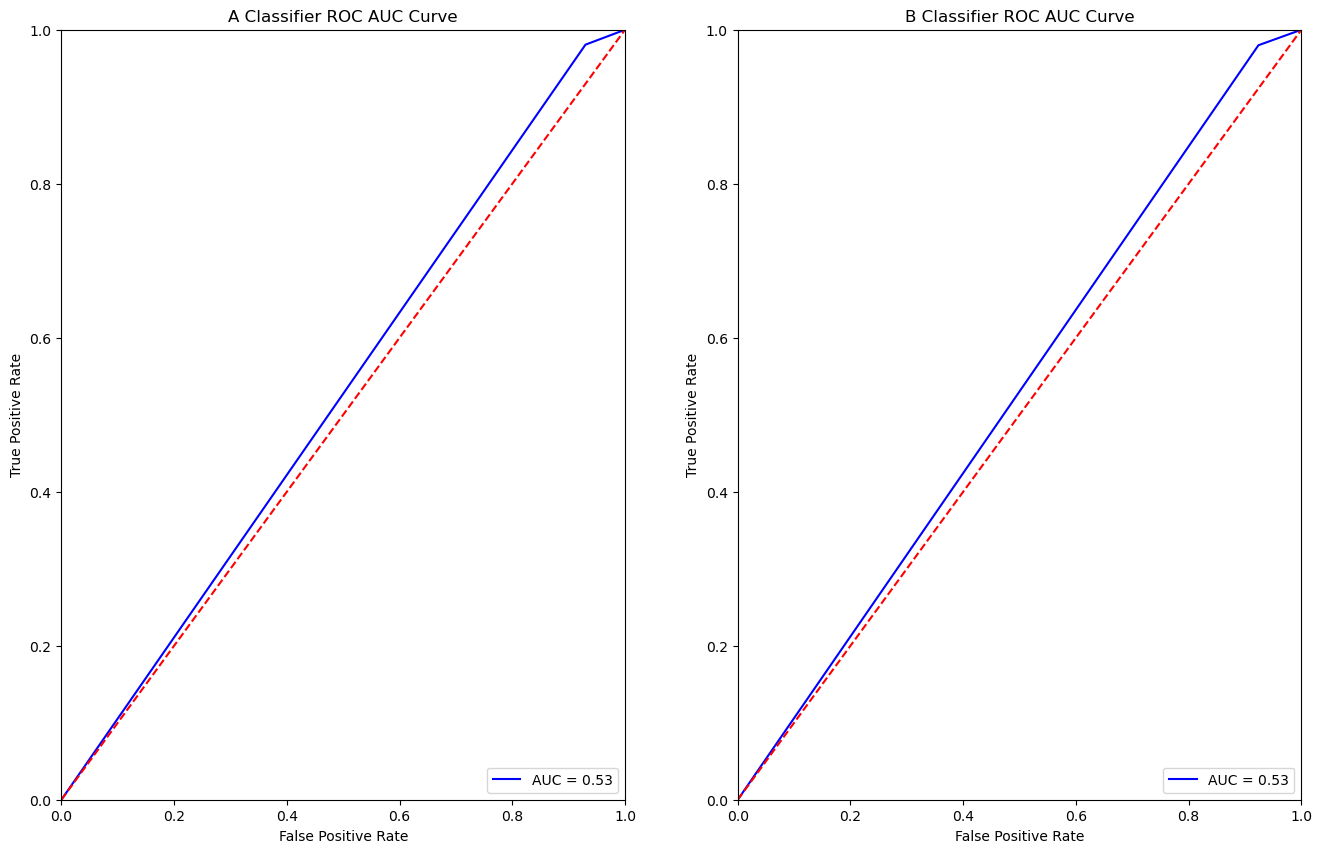

In [261]:
fig, ax = plt.subplots(1, 2, figsize=(16, 10))

ax[0].set_title('A Classifier ROC AUC Curve')
ax[0].plot(a_fpr, a_tpr, 'b', label = 'AUC = %0.2f' % a_roc_auc)
ax[0].legend(loc = 'lower right')
ax[0].plot([0, 1], [0, 1],'r--')
ax[0].set_xlim([0, 1])
ax[0].set_ylim([0, 1])
ax[0].set_ylabel('True Positive Rate')
ax[0].set_xlabel('False Positive Rate')

ax[1].set_title('B Classifier ROC AUC Curve')
ax[1].plot(b_fpr, b_tpr, 'b', label = 'AUC = %0.2f' % b_roc_auc)
ax[1].legend(loc = 'lower right')
ax[1].plot([0, 1], [0, 1],'r--')
ax[1].set_xlim([0, 1])
ax[1].set_ylim([0, 1])
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

plt.show()

**3.3** To determine if the differences in the classifiers from task **3.2** occur solely due to chance, follow the following bootstrap procedure, using 200 iterations:

- **A)** Randomly sample the entire dataset (i.e., votes from the dataframe constructed in task **3.1**) with replacement;
- **B)** Compute the difference of the AUC/ROC for the two classifiers on the entire dataset.

Then use the distribution of AUC/ROC differences (one difference per bootstrap iteration) to estimate the 95% confidence interval for the AUC/ROC difference.

In [264]:
# 3.3

auc_roc_differences = []

for i in range(200):
    sample = df.sample(frac=1, replace=True)

    y_true = sample["VOT"].map({-1: 0, 1: 1})

    a_fpr, a_tpr, a_roc_auc = evaluate_model(sample, a_classifier, y_true)
    b_fpr, b_tpr, b_roc_auc = evaluate_model(sample, b_classifier, y_true)

    auc_roc_differences.append(a_roc_auc - b_roc_auc)

print("95% CI:", np.quantile(np.array(auc_roc_differences), q=[0.025, 0.975]))

95% CI: [-0.00303181 -0.00230568]


**3.4 ** **/Discuss:**/ According to the results in tasks **3.2** and **3.3**, which theory better predicts actual edge signs, structural balance theory or the weak structural balance theory? 


**A3.4**

We confirmed with bootstrap sampling that the classifier B has a slightly better performance and predicts the actual edge signs more accurately than the A classifier. The difference is very tiny, in fact using bootstrap sampling with random samples with replacement we got a $[-0.0030, -0.0023]$ CI

**3.5** How accurately can we predict the vote with more sophisticated features and algorithms?

- Create a TF-IDF representation of the text of each vote  using `sklearn`'s vectorizer ([`sklearn.feature_extraction.text.TfidfVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)) with the parameters `max_features=150` and `stop_words='english'`.
- Split the  dataset into training and test sets using sklearn [`sklearn.model_selection.train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) using parameters `test_size=0.1` and  `random_state=42`.

- Then, train two logistic regression models ([`sklearn.linear_model.SGDClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html)) using parameters `loss='log_loss'` and `max_iter=2000` considering:

    - **1)** the TF-IDF feature vector

    - **2)** the TF-IDF feature vector and the features `PP`, `NN`, `PN`, `P`, and `N` related to the graph.

- Last, report the AUC/ROC of each model in the test set.

In [274]:
df["TXT_PROCESSED"] = df["TXT_PROCESSED"].fillna("")

In [283]:
# 3.5

from sklearn import feature_extraction, model_selection, linear_model
from sklearn.metrics import roc_auc_score


tfidf_vectorizer = feature_extraction.text.TfidfVectorizer(max_features=150, stop_words="english")
X = tfidf_vectorizer.fit_transform(df["TXT_PROCESSED"]).toarray()
X2 = np.hstack((X, df[["PP", "NN", "PN", "P", "N"]]))
y = (df["VOT"] == 1).astype(dtype=int)

x_train, x_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.1, random_state=42)
classifier = linear_model.SGDClassifier(loss="log_loss", max_iter=2000)
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)
auc_roc = roc_auc_score(y_test, y_pred)
print(f"AUC/ROC for model 1: {auc_roc}")

x_train, x_test, y_train, y_test = model_selection.train_test_split(X2, y, test_size=0.1, random_state=42)
classifier_2 = linear_model.SGDClassifier(loss="log_loss", max_iter=2000)
classifier_2.fit(x_train, y_train)
y_pred = classifier_2.predict(x_test)
auc_roc_2 = roc_auc_score(y_test, y_pred)
print(f"AUC/ROC for model 2: {auc_roc_2}")

AUC/ROC for model 1: 0.7043756425940187
AUC/ROC for model 2: 0.7964969951414118


**3.6** **/Discuss:**/  According to the results in task **3.5**, does information from the graph help in the task of predicting the vote even when using the text?  What kind of subsequent analysis would make you trust that the results are not obtained simply by chance? (No need to actually perform that subsequent analysis here.) 

**A3.6**

Including info from the graph helps a lot, raising the AUC/ROC score by about $0.092$, I would try another model that it is maybe not linear to see if it also gets similar performance and if it also finds very useful having some data from the graph. Also, very importantly I would try with many different train and test splits, maybe even building a confidence interval

**3.7** Putting on your observational studies hat, run two logistic regressions using `statsmodels`.
- In the first regression, the vote is the outcome, and `PP`, `NN` and `PN` are the predictors.
- In the second regression, the vote is the outcome, and `PP`, `NN`, `PN`, and `N` are the predictors.

In [ ]:
# 3.7
import statsmodels.formula.api as smf

df["VOT2"] = (df.VOT == 1).values.astype(int)
model_1 = smf.logit(formula='VOT2 ~ PP + NN + PN', data=df)
result_1 = model_1.fit()
print(result_1.summary())

Optimization terminated successfully.
         Current function value: 0.514594
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                   VOT2   No. Observations:               167003
Model:                          Logit   Df Residuals:                   166999
Method:                           MLE   Df Model:                            3
Date:                Fri, 02 Jan 2026   Pseudo R-squ.:                 0.01804
Time:                        22:06:05   Log-Likelihood:                -85939.
converged:                       True   LL-Null:                       -87517.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.2781      0.006    206.255      0.000       1.266       1.290
PP             0.2493      0.

In [287]:
model_2 = smf.logit(formula='VOT2 ~ PP + NN + PN + N', data=df)
result_2 = model_2.fit()
print(result_2.summary())

Optimization terminated successfully.
         Current function value: 0.487994
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                   VOT2   No. Observations:               167003
Model:                          Logit   Df Residuals:                   166998
Method:                           MLE   Df Model:                            4
Date:                Fri, 02 Jan 2026   Pseudo R-squ.:                 0.06880
Time:                        22:06:10   Log-Likelihood:                -81496.
converged:                       True   LL-Null:                       -87517.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.6227      0.008    212.945      0.000       1.608       1.638
PP             0.2535      0.

**3.8** **/Discuss:**/   Explain what the coefficient associated with `PP` means in the first regression. Is it in accordance with structural balance theory?

**A3.8**

It's definitely in accordance with the structural balance theory meaning that it's positive so the model tends to predict a positive vote for triangles where there are two positive links. 

**3.9** **/Discuss:**/   Compare the coefficients associated with `PN` and `NN` in the first vs. the second regression. Present a reason that may explain this difference.

**A3.9**

The only difference between the two models is that we added N to the model, this extra feature was not deemed very significant by the model but it makes the predicted vote be a little more negative, meaning that if the submission already received many negative votes it's more like that the next vote it's gonna receive it's negative. This explains overlaps with the PN case where expect to predict N. Also, PN and NN before adding N were already explaining some of the variance that N explains

---